In [2]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [24, 30, 22, 35],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston']
}

df = pd.DataFrame(data)
df.head()

,Name,Age,City
0,Alice,24,New York
1,Bob,30,Los Angeles
2,Charlie,22,Chicago
3,David,35,Houston


In [ ]:
reviews = pd.read_csv('reviews.csv')
reviews.tail(2)

In [ ]:
reviews.columns

In [ ]:
reviews.shape

In [ ]:
type(reviews)

In [ ]:
# slect col1 ,col 2 from reviews
reviews[['ProductId', 'UserId']].head(4)

In [ ]:
reviews[reviews['Score'] < 3].shape

In [ ]:
reviews.info()

In [ ]:
simple_data = {
    'product_category': ['Book', 'Book', 'Electronics', 'Clothing', 'Electronics'],
    'price': [12.99, 15.49, 199.99, 29.99, 99.99],
    'rating': [4.5, 4.0, 3.5, 5.0, 4.2]
}

df_simple = pd.DataFrame(simple_data)
df_simple.head()

In [ ]:
df_simple['discounted_price'] = df_simple['price'] * 0.9
df_simple.head()

In [ ]:
df_simple['pct_change_in_price']=df_simple['price'].pct_change()
df_simple.head()

In [ ]:
df_simple.product_category.value_counts()

In [ ]:
reviews['ProductId'].value_counts()

In [ ]:
reviews[reviews['ProductId']=='B0026RQTGE'].shape

In [ ]:
df_simple.price.describe()

In [ ]:
df_simple.describe(include='all',percentiles=[0.30,0.75, 0.99])  # include all data types

In [ ]:
df_simple

In [ ]:
df_simple.product_category.describe()

In [ ]:
df_simple.to_csv('simple_data.csv', index=False)
df_simple.to_excel('simple_data.xlsx', index=False)
df_simple.to_json('simple_data.json', index=False)
df_simple.to_html('simple_data.html', index=False)

In [ ]:
import pandas as pd
#  url = (
#     "https://raw.githubusercontent.com/pandas-dev"
#     "/pandas/main/pandas/tests/io/data/csv/tips.csv"
# )

tips = pd.read_csv('tips.csv')
tips.head(10)

In [ ]:
tips['new_total_bill'] = tips['total_bill'] - 2
tips['time'] = tips['time'].replace({'Dinner': 'Evening', 'Lunch': 'Afternoon'})
tips.head(10)

In [ ]:
condition = ( tips['day'] == 'Sun') & (tips['new_total_bill'] > 20)
tips[condition]

In [ ]:
def bucket_tip(tip):
    if tip < 5:
        return 'Low'
    elif tip < 10:
        return 'Medium'
    return 'High'


tips['tip_bucket'] = tips['tip'].apply(bucket_tip)
# tips.head(25)
print(tips['tip_bucket'].value_counts())
# tips.groupby('tip_bucket')['total_bill'].sum()

tips.groupby("tips_bucket")["total_bill"].apply(list).reset_index()
      

In [ ]:
tips.info()

In [ ]:
tips.isnull().count()

In [ ]:
test_df = pd.DataFrame({
    'A': [1, 2, None, 4],
    'B': [None, 2, 3, 4],
    'C': [1, None, None, 4],
    'D': [None, None, None, None]
})
test_df.index = ['row1', 'row2', 'row3', 'row4']
test_df.items().__dir__()
# test_df

In [ ]:
test_df.isnull().sum()

In [ ]:
# https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_spreadsheets.html#compare-with-spreadsheets

In [4]:
import pandas as pd
car_df = pd.read_csv('car_price_dataset_medium.csv')
car_df.rename(columns={'Price_USD': 'Price'}, inplace=True)
car_df.columns

Index(['Car_ID', 'Brand', 'Model_Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Engine_CC', 'Max_Power_bhp',
       'Mileage_kmpl', 'Seats', 'Price'],
      dtype='object')

In [4]:

condition = ( car_df['Price'] > 20000) & (car_df['Mileage_kmpl'] < 50000)
car_df[condition]
# both are same
car_df.query('Price > 20000 & Mileage_kmpl < 50000')


,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
6,7,Ford,2008,175604,Electric,Manual,First,3896,374.6,9.37,6,67839.21
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Volkswagen,2013,143440,Hybrid,Manual,First,3121,558.9,29.45,4,73873.86
996,997,Volkswagen,2021,90436,Electric,Automatic,Third,1295,437.8,10.01,6,115655.85
997,998,Kia,2015,51403,Electric,Manual,Second,4595,274.6,10.38,2,71968.08
998,999,Honda,2011,96170,Petrol,Manual,Third,2948,329.7,12.30,6,58127.19


In [ ]:
# car_df.head()

# car_df.head()
print(car_df.Brand.value_counts())
car_df.groupby('Brand').agg({
    'Price': ['mean', 'min', 'max']
})

In [5]:
report = car_df.groupby(['Brand','Fuel_Type']).agg({
    'Price': ['mean', 'min', 'max'],
    'Kilometers_Driven': ['mean', 'min', 'max']

})

report.reset_index()
# change the cells color where value > 50000
report

Price                      Kilometers_Driven  \
                              mean       min        max              mean   
Brand      Fuel_Type                                                        
Audi       Diesel     53277.218333   6647.46  119611.94     101066.111111   
           Electric   66219.721786   7718.63  117780.45     108908.928571   
           Hybrid     51630.635000   4853.05  108995.44      98900.000000   
           Petrol     70617.915667   3353.44  118402.94     102109.700000   
BMW        Diesel     48959.442000   6623.56  119074.79     100845.360000   
           Electric   54149.664737   3794.22  107571.58     114889.842105   
           Hybrid     58269.813529   3048.00  117970.33      98785.941176   
           Petrol     55973.224545   4081.27  113459.09     101222.818182   
Ford       Diesel     68400.834800  14579.33  115351.16     100745.720000   
           Electric   61466.326000   9612.34  117485.20     107817.866667   
           Hybrid     58267.564483   5446.41  119533.50      84362.206897   
           Petrol     51963.935769   8165.03  102004.68     117110.653846   
Honda      Diesel     52425.412857   3435.20  113093.00      94958.142857   
           Electric   53512.097143   3988.83  105829.09     116963.500000   
           Hybrid     71787.621429  32507.68  107608.69     103744.714286   
           Petrol     56580.663333   5597.73  118306.32      99301.333333   
Hyundai    Diesel     61928.550000   9473.89  113992.53     115716.000000   
           Electric   58432.903462   8237.90  117735.84      97195.884615   
           Hybrid     59517.330690   7071.51  117136.70     114020.689655   
           Petrol     55369.341429   5572.42  119200.16     102217.142857   
Kia        Diesel     61106.624545   4248.40  114842.50     104005.954545   
           Electric   49418.496296   4412.18  103893.19     108452.962963   
           Hybrid     58292.231538   5853.75  117194.36     106411.576923   
           Petrol     56590.960400   5589.73  113535.76     102874.400000   
Mercedes   Diesel     57420.207241   9089.36  114194.43      99399.655172   
           Electric   63856.970000   7166.62  119331.69      83433.956522   
           Hybrid     62423.763571   3092.37  115230.55     121419.428571   
           Petrol     74187.850741   4754.82  116927.88     107391.370370   
Nissan     Diesel     54568.085000   6606.48  108656.93     118871.416667   
           Electric   57270.161923   4595.86  114947.32      82736.076923   
           Hybrid     73774.305862   4076.51  112611.85     105457.000000   
           Petrol     64537.008750   3274.65  119508.88      75399.833333   
Toyota     Diesel     58689.083182   4522.19  116264.48     102730.000000   
           Electric   67885.625161  10605.09  116857.93     108034.258065   
           Hybrid     53863.721765   5109.75  118626.67     107561.852941   
           Petrol     55832.938065   4738.17  108473.84      95562.645161   
Volkswagen Diesel     59495.049583   6412.97  116750.88     131835.333333   
           Electric   61603.096071   4348.54  116846.31     106374.500000   
           Hybrid     57499.526429   5633.01  117201.16     105053.821429   
           Petrol     45477.434444   3028.42  119485.69      95489.629630   

                                     
                        min     max  
Brand      Fuel_Type                 
Audi       Diesel     11304  197018  
           Electric   25074  197699  
           Hybrid     12099  195736  
           Petrol     14686  189816  
BMW        Diesel      6283  195135  
           Electric   23313  199812  
           Hybrid     19849  170575  
           Petrol      5781  198783  
Ford       Diesel      5207  192598  
           Electric   21456  199718  
           Hybrid     10906  196703  
           Petrol     30169  195747  
Honda      Diesel     11910  190378  
           Electric   11548  168856  
           Hybrid      8191  197402  
           Petrol     10901  1990

In [ ]:
car_df.head()



Owner_Type Fuel_Type         Price                     Kilometers_Driven  \
                                 mean      min        max              mean   
0       First    Diesel  57969.032113  4248.40  119611.94     101597.760563   
1       First  Electric  63160.963704  3988.83  118345.44      97507.876543   
2       First    Hybrid  60460.390575  3048.00  117970.33     110166.195402   
3       First    Petrol  67616.404353  3274.65  118402.94     103123.776471   
4      Second    Diesel  56469.278289  3435.20  116595.85     103109.894737   
5      Second  Electric  65060.813250  4348.54  117780.45     112385.525000   
6      Second    Hybrid  59969.277647  4853.05  118626.67     100147.152941   
7      Second    Petrol  59611.012529  3083.87  119485.69      97410.413793   
8       Third    Diesel  58659.009872  4522.19  119074.79     112866.769231   
9       Third  Electric  52702.003736  3794.22  119331.69      99652.659341   
10      Third    Hybrid  60344.448625  5446.41  119533.50     104892.900000   
11      Third    Petrol  50495.392222  3028.42  119508.88      99572.474747   

                   
      min     max  
0    7839  197018  
1   11823  199812  
2    7336  197402  
3   11643  199018  
4    5587  197035  
5   10469  199718  
6   10075  195736  
7    5155  195864  
8    5163  199509  
9    8631  199442  
10   8191  196703  
11   5781  198021

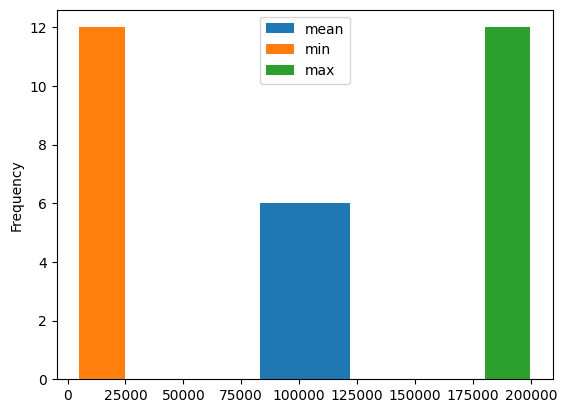

In [11]:
# I want to compare  avg price of cars based on Owner_type, Fuel_Type
report = car_df.groupby(['Owner_Type','Fuel_Type']).agg({
    'Price': ['mean', 'min', 'max'],
    'Kilometers_Driven': ['mean', 'min', 'max']
})
import matplotlib.pyplot as plt
# plot owner type vs avg price
# report.reset_index().plot(x='Fuel_Type', y=('Price','mean'), kind='bar')
report.reset_index().plot(x='Fuel_Type', y='Kilometers_Driven', kind='hist')

report.reset_index()

In [ ]:
# https://www.quora.com/What-is-the-difference-between-INNER-JOIN-LEFT-JOIN-and-RIGHT-JOIN-in-SQL-and-when-would-you-use-each-one

In [45]:
products = pd.DataFrame({
    'Prd_id': [1, 2, 3, 4, 5],
    'ProductName': ['Laptop', 'Smartphone', 'Tablet', 'Monitor', None]
})
print(products)
orders = pd.DataFrame({
    'OrderID': [101, 102, 103, 104],
    'ProductID': [1, 2, 9, 5],
    'Quantity': [1, 2, 1, 4]
})
print(orders)
# left join
left_join = pd.merge(products, orders, left_on='Prd_id', right_on='Quantity', how='right')
left_join

   Prd_id ProductName
0       1      Laptop
1       2  Smartphone
2       3      Tablet
3       4     Monitor
4       5        None
   OrderID  ProductID  Quantity
0      101          1         1
1      102          2         2
2      103          9         1
3      104          5         4


,Prd_id,ProductName,OrderID,ProductID,Quantity
0,1,Laptop,101,1,1
1,2,Smartphone,102,2,2
2,1,Laptop,103,9,1
3,4,Monitor,104,5,4


In [ ]:
df1 = pd.DataFrame(
    {
        "Price": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)
print(df1)

df2 = pd.DataFrame(
    {
        "Price": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
        "Age": ["A8", "A9", "A10", "A11"]
    },
    index=[4, 5, 6, 7],
)
print(df2)


df3 = pd.DataFrame(
    {
        "Age": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)
print(df3)

result = pd.concat([df1, df2, df3],axis=0)
result

# 0 means row-wise/index concatenation
# 1 means column-wise concatenation



  Price   B   C   D
0    A0  B0  C0  D0
1    A1  B1  C1  D1
2    A2  B2  C2  D2
3    A3  B3  C3  D3
  Price   B   C   D  Age
4    A4  B4  C4  D4   A8
5    A5  B5  C5  D5   A9
6    A6  B6  C6  D6  A10
7    A7  B7  C7  D7  A11
    Age    B    C    D
8    A8   B8   C8   D8
9    A9   B9   C9   D9
10  A10  B10  C10  D10
11  A11  B11  C11  D11


,Price,B,C,D,Age
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
4,A4,B4,C4,D4,A8
5,A5,B5,C5,D5,A9
6,A6,B6,C6,D6,A10
7,A7,B7,C7,D7,A11
8,NaN,B8,C8,D8,A8
9,NaN,B9,C9,D9,A9


In [ ]:
# change the cells color where value > 50
import pandas as pd
tech_products = pd.DataFrame({
    'Prd_id': [1, 2, 3, 4, 5],
    'ProductName': ['Laptop', 'Smartphone', 'Tablet', 'Monitor', None],
    'Price': [8, 6100, 30, 400, 111]
})

print(pd.cut(tech_products['Price'], bins=[0,100,300,500,700], labels=['Low','Medium','High','Very High']))
# tech_products[tech_products['Price'] > 50]
import jinja2 as jj
tech_products.style.background_gradient(cmap="Blues")

# def highlight_price_row(row):
#     return ['background-color: yellow' if row['Price'] > 50 else '' for _ in row]

# tech_products.style.apply(highlight_price_row, axis=1)

0       Low
1       NaN
2       Low
3      High
4    Medium
Name: Price, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']


ModuleNotFoundError: No module named 'jinja2'

In [55]:
car_df.head()
print('columns available:', car_df.columns.tolist())
car_df.isnull().sum()

columns available: ['Car_ID', 'Brand', 'Model_Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine_CC', 'Max_Power_bhp', 'Mileage_kmpl', 'Seats', 'Price']


Car_ID               0
Brand                0
Model_Year           0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Engine_CC            0
Max_Power_bhp        0
Mileage_kmpl         0
Seats                0
Price                0
dtype: int64

In [58]:
car_df[['Price','Seats','Kilometers_Driven','Engine_CC','Max_Power_bhp','Mileage_kmpl']].describe()

,Price,Seats,Kilometers_Driven,Engine_CC,Max_Power_bhp,Mileage_kmpl
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,59217.249420,4.665000,103397.074000,2878.299000,320.939900,17.34144
std,33545.254183,1.802783,57417.612935,1212.337697,160.384514,7.29799
min,3028.420000,2.000000,5155.000000,801.000000,40.500000,5.04000
25%,30030.822500,4.000000,52188.500000,1818.250000,184.825000,10.97000
50%,56806.745000,5.000000,102449.000000,2857.500000,314.650000,17.14500
75%,87088.897500,6.000000,152696.500000,3959.500000,455.300000,24.03500
max,119611.940000,7.000000,199812.000000,4996.000000,599.600000,29.99000


In [ ]:
car_df[car_df['Seats'] ==2].groupby('Brand').agg({
    'Price': ['mean', 'min', 'max'],
    'Kilometers_Driven': ['mean', 'min', 'max']
})


In [ ]:
car_df[car_df['Seats'] ==7].groupby('Brand').agg({
    'Price': ['mean', 'min', 'max'],
    'Kilometers_Driven': ['mean', 'min', 'max']
})

In [ ]:
# car_df.columns
# 'Car_ID', 'Brand', 'Model_Year', 'Kilometers_Driven', 'Fuel_Type',
#        'Transmission', 'Owner_Type', 'Engine_CC', 'Max_Power_bhp',
#        'Mileage_kmpl', 'Seats', 'Price'

# based on above col - create 10 questions
# Q) What is the average price of cars by brand?
# Q) How does the mileage vary across different fuel types?
# Q) What is the distribution of engine capacities among different brands?
# Q) How many seats do the cars have on average by transmission type?
# Q) What is the relationship between kilometers driven and price?
# Q) How does the maximum power output vary by fuel type?
# Q) What is the average price of cars with 2 seats?
# Q) How does the average mileage compare between petrol and diesel cars?
# Q) What is the trend in car prices over the years?
# Q) How do owner types affect the price of cars?

In [6]:
car_df

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Volkswagen,2013,143440,Hybrid,Manual,First,3121,558.9,29.45,4,73873.86
996,997,Volkswagen,2021,90436,Electric,Automatic,Third,1295,437.8,10.01,6,115655.85
997,998,Kia,2015,51403,Electric,Manual,Second,4595,274.6,10.38,2,71968.08
998,999,Honda,2011,96170,Petrol,Manual,Third,2948,329.7,12.30,6,58127.19


In [ ]:
# Q) What is the average price of cars by brand?
car_df.groupby('Brand').agg({
    'Price': ['mean', 'min', 'max']
})

Price                    
                    mean      min        max
Brand                                       
Audi        62351.394043  3353.44  119611.94
BMW         54154.605532  3048.00  119074.79
Ford        59953.021364  5446.41  119533.50
Honda       57226.331687  3435.20  118306.32
Hyundai     58818.596354  5572.42  119200.16
Kia         56090.171700  4248.40  117194.36
Mercedes    64344.239907  3092.37  119331.69
Nissan      64089.937473  3274.65  119508.88
Toyota      58964.422288  4522.19  118626.67
Volkswagen  55987.339720  3028.42  119485.69

In [ ]:
# Q) How does the mileage vary across different fuel types?
car_df.groupby('Fuel_Type').agg({
    'Mileage_kmpl': ['mean', 'min', 'max']
})  

# Q) What is the distribution of engine capacities among different brands?
car_df.groupby('Brand').agg({
    'Engine_CC': ['mean', 'min', 'max']
})

# Q) How many seats do the cars have on average by transmission type?
car_df.groupby('Transmission').agg({
    'Seats': ['mean', 'min', 'max']
})

# Q) How does the maximum power output vary by fuel type?
car_df.groupby('Fuel_Type').agg({
    'Max_Power_bhp': ['mean', 'min', 'max']
})
# import matplotlib.pyplot as plt
# # import seaborn as sns

# plt.figure(figsize=(8,5))
# # sns.barplot(data=df, x="Fuel_Type", y="Mileage_kmpl", ci=None, palette="viridis")

# plt.title("Average Mileage by Fuel Type")
# plt.ylabel("Mileage (kmpl)")
# plt.xlabel("Fuel Type")
# plt.show()


Mileage_kmpl             
                  mean   min    max
Fuel_Type                          
Diesel       17.442489  5.04  29.99
Electric     18.063889  5.18  29.77
Hybrid       17.334484  5.23  29.96
Petrol       16.592214  5.10  29.98

Price                    
                    mean      min        max
Owner_Type                                  
First       62466.937315  3048.00  119611.94
Second      60305.112500  3083.87  119485.69
Third       55166.335718  3028.42  119533.50

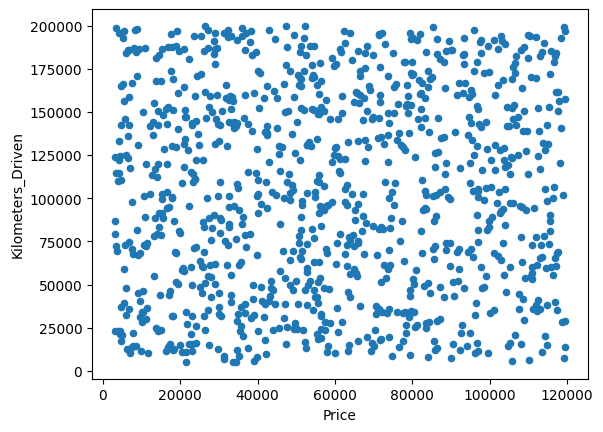

In [27]:
# Q) How does the average mileage compare between petrol and diesel cars?
car_df[car_df['Fuel_Type'].isin(['Petrol', 'Diesel'])].groupby('Fuel_Type').agg({
    'Mileage_kmpl': ['mean', 'min', 'max']
})

# Q) What is the trend in car prices over the years?
car_df.reset_index().plot(x='Price', y='Kilometers_Driven', kind='scatter')

# Q) How do owner types affect the price of cars?
car_df.groupby('Owner_Type').agg({
    'Price': ['mean', 'min', 'max']
})

Price                      Kilometers_Driven               
                    mean       min        max              mean    min     max
Brand                                                                         
Audi        66751.641429  15785.70  115645.82      96226.523810  24169  187503
BMW         44885.609565   3794.22  104684.59     112005.739130  19849  199812
Ford        61756.088800  10200.53  119533.50      80173.840000  10906  177927
Honda       48916.211481   3988.83  110006.38     106451.962963  11548  195864
Hyundai     60042.669167   8237.90  117136.70     113014.541667   9135  197660
Kia         52831.907917   4248.40  114260.14     116677.041667  20282  194784
Mercedes    65456.741600   5101.07  115230.55     104542.880000  10469  192686
Nissan      62951.544286   3274.65  112611.85     104156.809524   8471  198718
Toyota      58207.239091   4522.19  116857.93     107462.454545  15382  195546
Volkswagen  60996.445714   3028.42  119485.69     118146.476190   8754  199509

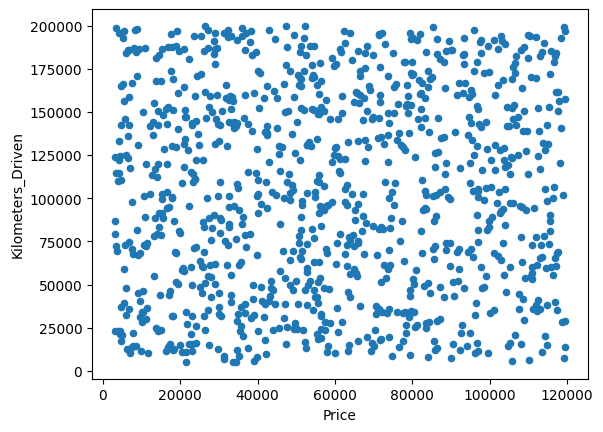

In [24]:
# Q) What is the relationship between kilometers driven and price?
# car_df.plot(x='Kilometers_Driven', y='Price', kind='scatter', alpha=1)
car_df.reset_index().plot(x='Price', y='Kilometers_Driven', kind='scatter')
# Q) What is the average price of cars with 2 seats?
car_df[car_df['Seats'] ==2].groupby('Brand').agg({
    'Price': ['mean', 'min', 'max'],
    'Kilometers_Driven': ['mean', 'min', 'max']
})


In [2]:
import pandas as pd

df = pd.DataFrame({"A": [1, 2, 3]})
df.style.highlight_max()

AttributeError: The '.style' accessor requires jinja2